# Fused Gromov-Wasserstein (FGW) Distance with k-hop Structural Information

This notebook demonstrates how to compute FGW distances between graphs using different powers of the adjacency matrix to capture k-hop structural information.

In [1]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import ot
from utils import random_adj_from_gt
from conformal.FGW import Graph, fgw_k
from scipy.sparse.csgraph import shortest_path


In [2]:
# Node features (3 color classes)
F_gt = np.array([
    [1, 0, 0],  # blue
    [1, 0, 0],  # blue
    [0, 1, 0],  # green
    [0, 1, 0],  # green
    [0, 0, 1],  # red
])

# Adjacency matrix (5x5 graph)
A_gt = np.array([
    [0, 1, 0, 0, 1],
    [1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1],
    [1, 0, 0, 1, 0],
], dtype=float)

# Create ground truth graph
gt = Graph(A=A_gt, F=F_gt)
print(f"Ground truth graph: {gt.A.shape[0]} nodes")

Ground truth graph: 5 nodes


In [3]:
# Start with ground truth in the candidate set
candidate_set = [gt]

# Generate 9 noisy variations with higher noise level
for i in range(9):
    A_i = random_adj_from_gt(A_gt, noise_level=0.4, seed=i)
    candidate_set.append(Graph(A=A_i, F=F_gt))

print(f"Candidate set size: {len(candidate_set)} graphs")

Candidate set size: 10 graphs


In [4]:
# Create prediction graph with lower noise level
A_pred = random_adj_from_gt(A_gt, noise_level=0.15, seed=123)
pred_graph = Graph(A=A_pred, F=F_gt)

print(f"Prediction graph: {pred_graph.A.shape[0]} nodes")

Prediction graph: 5 nodes


In [5]:
# Define k values to test
ks = [1,2,3]

# Initialize storage for distances
fgw_pred = {k: [] for k in ks}
fgw_gt = {k: [] for k in ks}

# Compute FGW distances for each k
for k in ks:
    print(f"Computing FGW_{k}...")
    for g in candidate_set:
        fgw_pred[k].append(fgw_k(pred_graph, g, k) )
        fgw_gt[k].append(fgw_k(gt, g, k) )

# Convert to numpy arrays
for k in ks:
    fgw_pred[k] = np.array(fgw_pred[k])
    fgw_gt[k] = np.array(fgw_gt[k])

print("✓ FGW distances computed for all k values")

Computing FGW_1...
Computing FGW_2...
Computing FGW_3...
✓ FGW distances computed for all k values


In [11]:
# Normalize distances to [0, 1] for each k
for k in ks:
    # Normalize pred distances
    min_pred = fgw_pred[k].min()
    max_pred = fgw_pred[k].max()
    if max_pred > min_pred:
        fgw_pred[k] = (fgw_pred[k] - min_pred) / (max_pred - min_pred)
    
    # Normalize gt distances
    min_gt = fgw_gt[k].min()
    max_gt = fgw_gt[k].max()
    if max_gt > min_gt:
        fgw_gt[k] = (fgw_gt[k] - min_gt) / (max_gt - min_gt)

print("✓ Distances normalized to [0, 1]")

✓ Distances normalized to [0, 1]


In [6]:
def fgw_distance(G1: Graph, G2: Graph, alpha: float = 0.5, k=1) -> float:
    """
    Compute FGW distance between two Graph objects.
    """

    # Number of nodes
    n1 = G1.F.shape[0]
    n2 = G2.F.shape[0]

    # Uniform node measures
    p1 = ot.unif(n1)
    p2 = ot.unif(n2)

    loss_fun = "square_loss"

    # Feature cost matrix (squared Euclidean), written explicitly
    Y_norms = np.linalg.norm(G1.F, axis=1) ** 2
    Z_norms = np.linalg.norm(G2.F, axis=1) ** 2
    scalar_products = G1.F @ G2.F.T

    M = (
        Y_norms.reshape(-1, 1)
        + Z_norms.reshape(1, -1)
        - 2 * scalar_products
    )

    A_1= shortest_path(G1.A, directed=False, unweighted=True)
    A_1 = np.linalg.matrix_power(A_1, k)
    A_2= shortest_path(G2.A, directed=False, unweighted=True)
    A_2 = np.linalg.matrix_power(A_2, k)
        
    
    # FGW (POT objective value)
    d = ot.gromov.fused_gromov_wasserstein2(
        M,
        A_1,
        A_2,
        p1,
        p2,
        loss_fun=loss_fun,
        alpha=alpha,
    )

    return d


In [7]:
fgw_distance(gt, gt)

1.1102230246251565e-16

In [10]:
fgw_k(gt,gt, k=1, sp=True)

5.551115123125783e-17

## Issue: Why is fgw_k(gt, gt, k=1) not zero?

The problem is that FGW expects **structure dissimilarity matrices** (like shortest path distances), not raw adjacency matrices. When we pass A directly, it treats edges as "distances", which is incorrect.

**Solution:** Convert adjacency to proper distance matrices.

In [34]:
# Let's check what's happening
print("Feature distance matrix C (should be all zeros for gt vs gt):")
C = ot.dist(gt.F, gt.F, metric="euclidean")
print(C)
print(f"\nMax value: {C.max()}")

print("\n" + "="*50)
print("Adjacency matrix A:")
print(gt.A)

print("\n" + "="*50)
print("The issue: A is being used as a 'structure cost matrix'")
print("But A encodes edges (0=no edge, 1=edge), not distances!")
print("For GW/FGW, we need dissimilarity matrices.")

Feature distance matrix C (should be all zeros for gt vs gt):
[[0.         0.         1.41421356 1.41421356 1.41421356]
 [0.         0.         1.41421356 1.41421356 1.41421356]
 [1.41421356 1.41421356 0.         0.         1.41421356]
 [1.41421356 1.41421356 0.         0.         1.41421356]
 [1.41421356 1.41421356 1.41421356 1.41421356 0.        ]]

Max value: 1.4142135623730951

Adjacency matrix A:
[[0. 1. 0. 0. 1.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0.]]

The issue: A is being used as a 'structure cost matrix'
But A encodes edges (0=no edge, 1=edge), not distances!
For GW/FGW, we need dissimilarity matrices.


## 8. Visualize Results

Create a scatter plot comparing FGW_k distances for different k values.

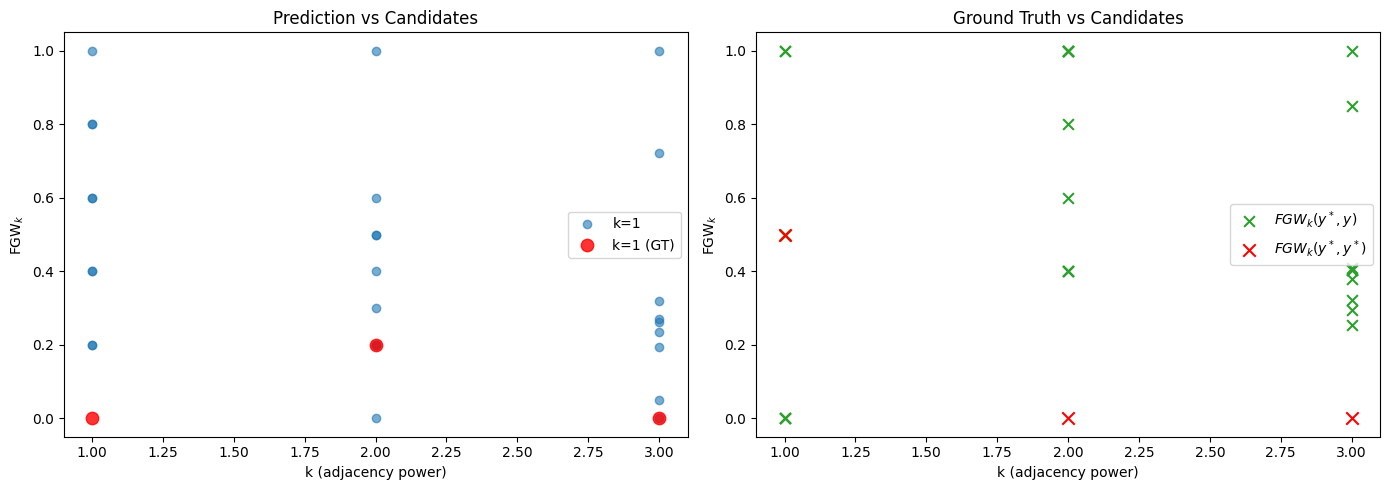

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Pred vs candidates
for k in ks:
    # Plot non-GT candidates
    ax1.scatter(
        [k] * (len(candidate_set) - 1),
        fgw_pred[k][1:],
        color="tab:blue",
        alpha=0.6,
        label=f"k={k}" if k == ks[0] else None,
    )
    # Plot GT candidate in red
    ax1.scatter(
        k,
        fgw_pred[k][0],
        color="red",
        alpha=0.8,
        marker='o',
        s=80,
        label=f"k={k} (GT)" if k == ks[0] else None,
    )

ax1.set_xlabel("k (adjacency power)")
ax1.set_ylabel(r"$\mathrm{FGW}_k$")
ax1.set_title("Prediction vs Candidates")
ax1.legend()

# Right plot: GT vs candidates
for k in ks:
    # Plot non-GT candidates
    ax2.scatter(
        [k] * (len(candidate_set) - 1),
        fgw_gt[k][1:],
        color="tab:green",
        marker="x",
        s=60,
        label=r"$FGW_k(y^*, y)$" if k == ks[0] else None,
    )
    # Plot GT vs GT in red
    ax2.scatter(
        k,
        fgw_gt[k][0],
        color="red",
        marker='x',
        s=80,
        label=r"$FGW_k(y^*, y^*)$" if k == ks[0] else None,
    )

ax2.set_xlabel("k (adjacency power)")
ax2.set_ylabel(r"$\mathrm{FGW}_k$")
ax2.set_title("Ground Truth vs Candidates")
ax2.legend()

plt.tight_layout()
plt.show()